# Задача 1

С изображениями из директории (https://drive.google.com/drive/folders/1sPwKGt_BX0fwGFTwVcoC7opwLT41b9Ug?usp=sharing)
1. Реализуйте загрузку изображений из директории применив трансформации изменения размера изображения, вращения и преобразования изображения в тензор.
2. Создайте DataLoader, задайте batch_size = 16 с перемешиванием данных.
3. Распечатайте shape и метки первых 10 изображений в датасете
4. Распечатайте shape и метки первых 10 изображений в датасете путем создания подмножества Subset
5. Распечатайте индексы, shape и метки для первых 10 изображений с использованием enumerate(dataset)
6. Разбейте данные на тренировочную и тестовую выборки в отншении 0.7 и 0.3 соответственно и распечатайте первые 5 меток из каждой выборки

In [1]:
import zipfile
import os

In [ ]:
zip_files = ['Apple___Apple_scab-20250307T125959Z-001.zip', 'Apple___Black_rot-20250307T125955Z-001.zip', 'Apple___Cedar_apple_rust-20250307T125952Z-001.zip', 'Apple___healthy-20250307T125949Z-001.zip']

temp_dir = 'temp_extracted'
os.makedirs(temp_dir, exist_ok=True)

# Распаковываем каждый zip-файл в отдельную папку внутри temp_dir
for zip_file in zip_files:
    folder_name = os.path.splitext(os.path.basename(zip_file))[0]
    folder_path = os.path.join(temp_dir, folder_name)
    os.makedirs(folder_path, exist_ok=True)

    with zipfile.ZipFile(zip_file, 'r') as z:
        z.extractall(folder_path)
        print(f'Извлечён {zip_file} в {folder_path}')

# Создаём новый zip-файл, в который добавляем все извлечённые файлы
combined_zip = 'combined.zip'
with zipfile.ZipFile(combined_zip, 'w') as newzip:
    for foldername, subfolders, filenames in os.walk(temp_dir):
        for filename in filenames:
            file_path = os.path.join(foldername, filename).
            arcname = os.path.relpath(file_path, temp_dir)
            newzip.write(file_path, arcname)
            print(f'Добавлен файл: {arcname}')

print(f'Новый архив создан: {combined_zip}')


Извлечён Apple___Apple_scab-20250307T125959Z-001.zip в temp_extracted/Apple___Apple_scab-20250307T125959Z-001
Извлечён Apple___Black_rot-20250307T125955Z-001.zip в temp_extracted/Apple___Black_rot-20250307T125955Z-001
Извлечён Apple___Cedar_apple_rust-20250307T125952Z-001.zip в temp_extracted/Apple___Cedar_apple_rust-20250307T125952Z-001
Извлечён Apple___healthy-20250307T125949Z-001.zip в temp_extracted/Apple___healthy-20250307T125949Z-001
Добавлен файл: Apple___Black_rot-20250307T125955Z-001/Apple___Black_rot/image (122).JPG
Добавлен файл: Apple___Black_rot-20250307T125955Z-001/Apple___Black_rot/image (496).JPG
Добавлен файл: Apple___Black_rot-20250307T125955Z-001/Apple___Black_rot/image (576).JPG
Добавлен файл: Apple___Black_rot-20250307T125955Z-001/Apple___Black_rot/image (588).JPG
Добавлен файл: Apple___Black_rot-20250307T125955Z-001/Apple___Black_rot/image (129).JPG
Добавлен файл: Apple___Black_rot-20250307T125955Z-001/Apple___Black_rot/image (261).JPG
Добавлен файл: Apple___Black

## Задание 1

In [ ]:
!unzip -q combined.zip -d combined

In [12]:
import torch
from torchvision import transforms, datasets
from torch.utils.data import DataLoader, Subset, random_split
import matplotlib.pyplot as plt

In [ ]:
data_dir = 'combined'

# Определяем последовательность преобразований:
# - Изменение размера до 128x128 (можно изменить под нужный размер)
# - Случайное вращение изображения на угол до 20 градусов
# - Преобразование изображения в тензор
transform = transforms.Compose([
    transforms.Resize((128, 128)),
    transforms.RandomRotation(20),
    transforms.ToTensor()
])

In [ ]:
dataset = datasets.ImageFolder(root=data_dir, transform=transform)

dataloader = DataLoader(dataset, batch_size=32, shuffle=True)

# Проверим, как выглядит один батч изображений
images, labels = next(iter(dataloader))
print("Размер батча:", images.shape)

Размер батча: torch.Size([32, 3, 128, 128])


## Задание 2 - 6


In [ ]:
# 2. Создаём DataLoader с batch_size = 16 и перемешиванием данных.
dataloader = DataLoader(dataset, batch_size=16, shuffle=True)
print("DataLoader создан с batch_size=16 и shuffle=True\n")

DataLoader создан с batch_size=16 и shuffle=True



In [ ]:
# 3. Распечатываем shape и метки первых 10 изображений в датасете напрямую
print("Первые 10 изображений в датасете (без Subset):")
for i in range(10):
    img, label = dataset[i]
    print(f"Изображение {i}: shape = {img.shape}, label = {label}")

Первые 10 изображений в датасете (без Subset):
Изображение 0: shape = torch.Size([3, 128, 128]), label = 0
Изображение 1: shape = torch.Size([3, 128, 128]), label = 0
Изображение 2: shape = torch.Size([3, 128, 128]), label = 0
Изображение 3: shape = torch.Size([3, 128, 128]), label = 0
Изображение 4: shape = torch.Size([3, 128, 128]), label = 0
Изображение 5: shape = torch.Size([3, 128, 128]), label = 0
Изображение 6: shape = torch.Size([3, 128, 128]), label = 0
Изображение 7: shape = torch.Size([3, 128, 128]), label = 0
Изображение 8: shape = torch.Size([3, 128, 128]), label = 0
Изображение 9: shape = torch.Size([3, 128, 128]), label = 0


In [ ]:
# 4. Распечатываем shape и метки первых 10 изображений с использованием Subset
subset_10 = Subset(dataset, list(range(10)))
print("\nПервые 10 изображений с использованием Subset:")
for i, (img, label) in enumerate(subset_10):
    print(f"Изображение {i}: shape = {img.shape}, label = {label}")



Первые 10 изображений с использованием Subset:
Изображение 0: shape = torch.Size([3, 128, 128]), label = 0
Изображение 1: shape = torch.Size([3, 128, 128]), label = 0
Изображение 2: shape = torch.Size([3, 128, 128]), label = 0
Изображение 3: shape = torch.Size([3, 128, 128]), label = 0
Изображение 4: shape = torch.Size([3, 128, 128]), label = 0
Изображение 5: shape = torch.Size([3, 128, 128]), label = 0
Изображение 6: shape = torch.Size([3, 128, 128]), label = 0
Изображение 7: shape = torch.Size([3, 128, 128]), label = 0
Изображение 8: shape = torch.Size([3, 128, 128]), label = 0
Изображение 9: shape = torch.Size([3, 128, 128]), label = 0


In [ ]:
# 5. Распечатываем индексы, shape и метки для первых 10 изображений с использованием enumerate(dataset)
print("\nПервые 10 изображений с использованием enumerate(dataset):")
for idx, (img, label) in enumerate(dataset):
    if idx >= 10:
        break
    print(f"Индекс {idx}: shape = {img.shape}, label = {label}")


Первые 10 изображений с использованием enumerate(dataset):
Индекс 0: shape = torch.Size([3, 128, 128]), label = 0
Индекс 1: shape = torch.Size([3, 128, 128]), label = 0
Индекс 2: shape = torch.Size([3, 128, 128]), label = 0
Индекс 3: shape = torch.Size([3, 128, 128]), label = 0
Индекс 4: shape = torch.Size([3, 128, 128]), label = 0
Индекс 5: shape = torch.Size([3, 128, 128]), label = 0
Индекс 6: shape = torch.Size([3, 128, 128]), label = 0
Индекс 7: shape = torch.Size([3, 128, 128]), label = 0
Индекс 8: shape = torch.Size([3, 128, 128]), label = 0
Индекс 9: shape = torch.Size([3, 128, 128]), label = 0


In [ ]:
# 6. Разбиваем данные на тренировочную (70%) и тестовую (30%) выборки
dataset_size = len(dataset)
train_size = int(0.7 * dataset_size)
test_size = dataset_size - train_size

train_dataset, test_dataset = random_split(dataset, [train_size, test_size])
print(f"\nРазмеры датасета: {dataset_size} изображений, тренировка: {train_size}, тест: {test_size}")

# Распечатываем первые 5 меток из тренировочной выборки
print("\nПервые 5 меток тренировочной выборки:")
for i in range(5):
    _, label = train_dataset[i]
    print(f"Тренировочное изображение {i}: label = {label}")

# Распечатываем первые 5 меток из тестовой выборки
print("\nПервые 5 меток тестовой выборки:")
for i in range(5):
    _, label = test_dataset[i]
    print(f"Тестовое изображение {i}: label = {label}")


Размеры датасета: 2226 изображений, тренировка: 1558, тест: 668

Первые 5 меток тренировочной выборки:
Тренировочное изображение 0: label = 3
Тренировочное изображение 1: label = 2
Тренировочное изображение 2: label = 0
Тренировочное изображение 3: label = 1
Тренировочное изображение 4: label = 3

Первые 5 меток тестовой выборки:
Тестовое изображение 0: label = 0
Тестовое изображение 1: label = 0
Тестовое изображение 2: label = 3
Тестовое изображение 3: label = 3
Тестовое изображение 4: label = 0


# Задача 2

С изображениями из директории (https://drive.google.com/drive/folders/1sPwKGt_BX0fwGFTwVcoC7opwLT41b9Ug?usp=sharing) сделайте вывод одного батча изображений (batch_size=16) с названиями класса на каждом изображении

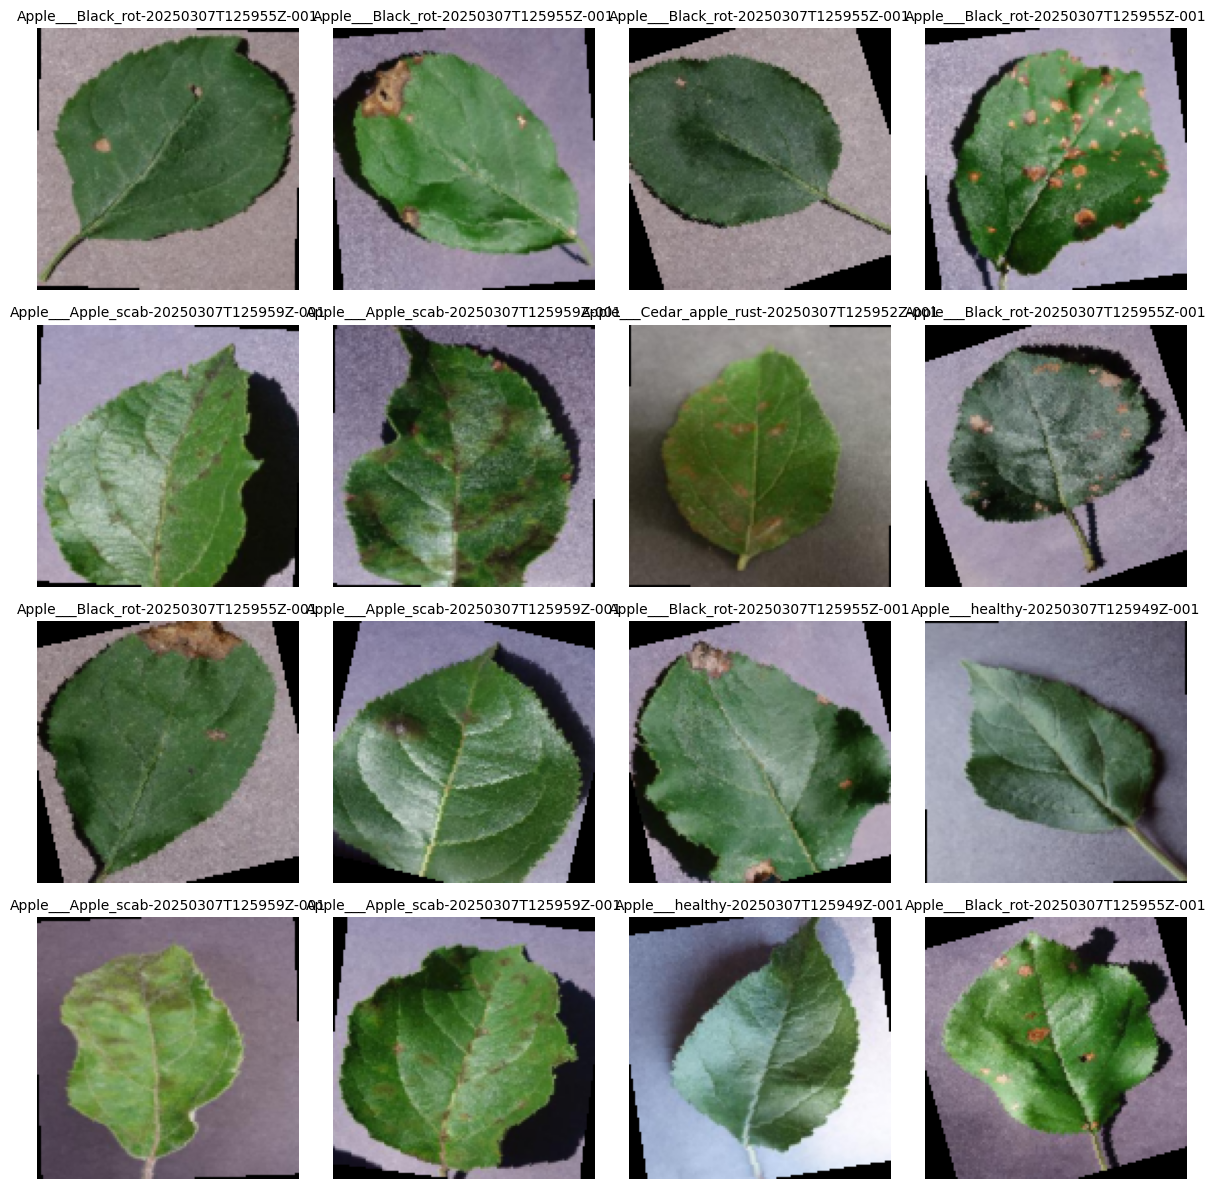

In [ ]:
images, labels = next(iter(dataloader))

class_names = dataset.classes

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
axes = axes.flatten()

for idx, ax in enumerate(axes):
    # Преобразуем тензор изображения (C, H, W) в формат (H, W, C) для matplotlib
    img = images[idx].permute(1, 2, 0)
    label = labels[idx].item()
    class_name = class_names[label]
    ax.imshow(img)
    ax.set_title(class_name, fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Задача 3

Создайте кастомный класс для загрузки данных из [директории](https://drive.google.com/drive/folders/1r0PvRCsrqBpRe6bj1aw8bLwkEfAbC9lo?usp=sharing). Вывести размер датасета и вывести изображение с id = 200.

In [16]:
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

class CatsAndDogsDataset(Dataset):
    def __init__(self, root_dir, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        self.image_paths = []
        self.labels = []

        for label, category in enumerate(['cats', 'dogs']):
            category_dir = os.path.join(root_dir, category)
            for img_name in os.listdir(category_dir):
                img_path = os.path.join(category_dir, img_name)
                self.image_paths.append(img_path)
                self.labels.append(label)

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = Image.open(img_path).convert('RGB')

        if self.transform:
            image = self.transform(image)

        label = self.labels[idx]
        return image, label





transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
])

train_path = 'cats_and_dogs/train'
test_path = 'cats_and_dogs/test'

train_dataset = CatsAndDogsDataset(root_dir=train_path, transform=transform)
test_dataset = CatsAndDogsDataset(root_dir=test_path, transform=transform)

train_dataloader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=True)


train_data_iter = iter(train_dataloader)
train_images, train_labels = next(train_data_iter)

print(f"Размер батча: {train_images.size()}")
print(f"Метки: {train_labels}")

Размер батча: torch.Size([16, 3, 224, 224])
Метки: tensor([1, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 0, 0])
